<a href="https://colab.research.google.com/github/ColeDeBois/Altmanlab/blob/main/Example_of_Calibrating_using_the_Entire_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount the Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# The code below sets the initial conditions and creates functions that are used later

In [ ]:
# import libraries
from __future__ import division
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import curve_fit
from scipy import signal
import warnings
#warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)
from tkinter import filedialog
from scipy.signal import welch #, hamming
from scipy.fft import fft, fftfreq
import glob
import tkinter

# define constants
fs = 50000  # data collection rate
dt = 1/fs
kBT = 4.11e-21     # room temp (J)
eta = 0.001  # Pa s, viscosity of water
#eta = 0.002548 # Pa s, viscosity of BSA solution
#eta = 0.001856 # Pa s

r = (2.0e-6)/2      # radius of bead
D = kBT /(6*np.pi*eta*r)    # diffusion constant
beta = 6*np.pi*eta*r

In [ ]:
# Create functions

def calcpowerspec2(data):    # Calculate power spectrum
    f, Pxx_den = signal.welch(data, fs,  nperseg=int(len(data)), window='hamming')
    return f, Pxx_den

def openfile(filename):   # open files
    fid = open(filename, 'rb')
    dim = np.fromfile(fid, dtype='>d')
    fid.close()
    return dim

def autocorrFFT(x):     # used by the program that calculates the meansquared displacement
    N=len(x)
    F = np.fft.fft(x, n=2*N)  #2*N because of zero-padding
    PSD = F * F.conjugate()
    res = np.fft.ifft(PSD)
    res= (res[:N]).real   #now we have the autocorrelation in convention B
    n=N*np.ones(N)-np.arange(0,N) #divide res(m) by (N-m)
    return res/n #this is the autocorrelation in convention A

def msd_fft(x, y):      # calculate the mean squared displacement
    # Organize the data into a 2-column array where each row contains an x and y position
    r = np.ones((int(len(x)), 2))
    for i in range(0,int(len(x))):
        values = [x[i], y[i]]
        r[i] =  values

    # calculate the MSD using the FFT
    N=len(r)
    D=np.square(r).sum(axis=1)
    D=np.append(D,0)
    S2=sum([autocorrFFT(r[:, i]) for i in range(r.shape[1])])
    Q=2*D.sum()
    S1=np.zeros(N)
    for m in range(N):
        Q=Q-D[m-1]-D[N-m]
        S1[m]=Q/(N-m)
    msdval = S1-2*S2
    tau = np.multiply(dt, [i for i in range(0, len(msdval))])
    msdvalues = pd.DataFrame({'tau': tau, 'msd': msdval})
    return msdvalues

def func(x, a, b):    # fitting function for the PSD
    return a**2*(D/((np.pi)**2)) / ( (b/(2*np.pi*beta))**2 + x**2) # from eqn 10 Berg-Sorensen et al. 2004
       # a - Sensitivity - units of V/m
       # b - Stiffness - N/m

def loaddata(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    # longdatax = (longdatax)/(Sx/1e9)-trapx
    # longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatax = (longdatax)/(Sx)    # all in meters
    longdatay = (longdatay)/(Sy)    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg

# LOW PASS FILTER
def loaddatafilter(basename, firstnumber, lastnumber, PSflag, frequency):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(5001)
  powerspecy = np.zeros(5001)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 5
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    #longdatax = (longdatax)/(Sx/1e9)-trapx
    #longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatax = (longdatax)/(Sx)    # all in meters
    longdatay = (longdatay)/(Sy)    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')


  sos = signal.butter(10, frequency, 'hp', fs=50000, output='sos')
  longdatax = signal.sosfilt(sos, longdatax)
  longdatay = signal.sosfilt(sos, longdatay)

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg


def loaddataquiet(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:
        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    longdatax = (longdatax)/(Sx)    # all in meters
    longdatay = (longdatay)/(Sy)    # all in meters

  else:
    pass

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg


def loaddataquiet_nocalib(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:
        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg




def calibrate(xb, yb, sumsignalb, f, powerspecx, powerspecy):
  # Calibrate the trap/detector

  initial = 8  # starting frequency for the fit
  list = [i for i in range(len(f)) if f[i] > 4000]     # final frequency
  final = list[0]

  t = dt*np.arange(0, len(xb))
  plt.figure(100)
  plt.loglog(f, powerspecx, 'k.')
  plt.xlabel('frequency [Hz]')
  plt.ylabel('PSD$_x$ [V$^2$/Hz]')
  plt.figure(101)
  plt.loglog(f, powerspecy, 'k.', label = 'Experimental Power Spectrum' )
  plt.axis('tight')
  plt.xlabel('frequency [Hz]')
  plt.ylabel('PSD$_y$ [V$^2$/Hz]')
  plt.legend()

  # Fit the power spectral density - x
  poptx, pcov = curve_fit(func, f[initial:final], powerspecx[initial:final], [100000, 0.001])
  alphax = np.abs(poptx[1])
  print('spring constant x (PS): ' + str(alphax*1e3), ' pN/nm')
  print('spring constant x (var): ' + str(kBT / np.var(xb[0:int(fs/50)]/poptx[0])*1e3), ' pN/nm')
  print('Sensitivity : ' + str(poptx[0]/1e6) + ' V/um')
  plt.figure(100)
  plt.plot(f[initial:final], func(f[initial:final], *poptx), 'r-')
  print('****************')
  # Fit the power spectral density - y
  popty, pcov = curve_fit(func, f[initial:final], powerspecy[initial:final], [100000, 0.001])
  alphay = np.abs(popty[1])
  print('spring constant y (PS): ' + str(alphay*1e3), ' pN/nm')
  print('spring constant y (var): ' + str(kBT / np.var(yb[0:int(fs/50)]/popty[0])*1e3), ' pN/nm')
  print('Sensitivity y: ' + str(popty[0]/1e6) + ' V/um')
  plt.figure(101)
  plt.plot(f[initial:final], func(f[initial:final], *popty), 'r-',
         label = 'Theoretical Power Spectrum')
  plt.legend()

  global kx
  global ky
  kx = alphax
  ky = alphay

  global Sx
  global Sy
  Sx = np.abs(poptx[0])  # units of V/m -- divide voltages by this to convert to distances
  Sy = np.abs(popty[0])  # units of V/m -- divide voltages by this to convert to distances

  plt.figure()
  plt.subplot(3, 1, 1)
  plt.plot(t, (xb)/(Sx/1e9) , 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('x [nm]')
  plt.subplot(3, 1, 2)
  plt.plot(t, (yb)/(Sy/1e9) , 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('y [nm]')
  plt.subplot(3, 1, 3)
  plt.plot(t, sumsignalb, 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('sum signal [V]')

  xb = (xb)/(Sx)  # units of m
  yb = (yb)/(Sy)  # units of m

  global trapx
  global trapy
  trapx = np.mean(xb) # Center of optical trap - x (m)
  trapy = np.mean(yb) # Center of optical trap - y (m)

def calcmsd(xb, yb):    # This calculates the MSD using the brute force approach
  # Calculate the MSD
  analysislength = 30   # the length of data that will be analyzed
  msdlength = 10      # the maximum value of tau plotted for the MSD plot

  # Select Brownian data to analyze MSD and Fourier transform
  xbrown = xb[0:int(analysislength/dt)]
  ybrown = yb[0:int(analysislength/dt)]

  msdvaluesbrown = msd_fft(xbrown, ybrown)
  plt.figure()
  plt.loglog(msdvaluesbrown.tau[1:int(msdlength/(dt))], msdvaluesbrown.msd[1:int(msdlength/(dt))], 'b.', label = 'Bead in the Optical Trap')
  plt.figure()
  msddatabrown = np.array(msdvaluesbrown.msd[1:int(msdlength/dt)]) / (1e18)
  N = len(msddatabrown)
  T = 1/fs
  yfbrown = fft(xbrown)
  xfbrown = fftfreq(N, T)[:N//2]
  plt.plot(xfbrown[1000:3000], 2.0/N * np.abs(yfbrown[1000:3000]))
  plt.xlabel('frequency (Hz)')
  plt.title('Fourier transform of MSD')
  plt.show()
  return msdvaluesbrown

# STEP 1: Analyze the Brownian motion data to calibrate the trap and detector

spring constant x (PS): 0.03257773752976047  pN/nm
spring constant x (var): 0.03598450908538703  pN/nm
Sensitivity : 1.7417645874005996 V/um
****************
spring constant y (PS): 0.02887465110859419  pN/nm
spring constant y (var): 0.036414331041116674  pN/nm
Sensitivity y: 1.625326375294891 V/um


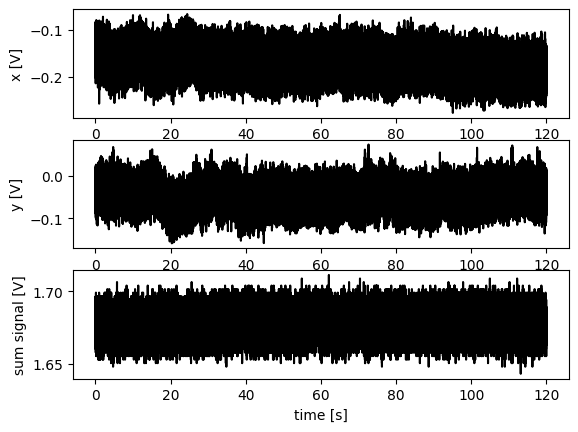

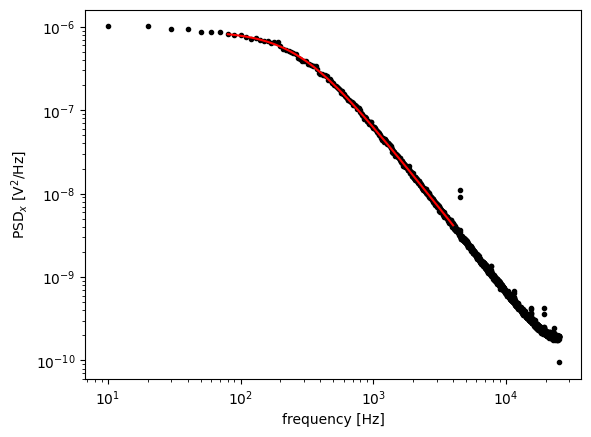

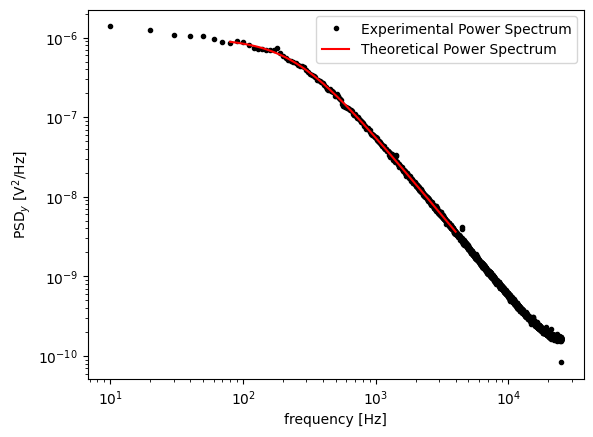

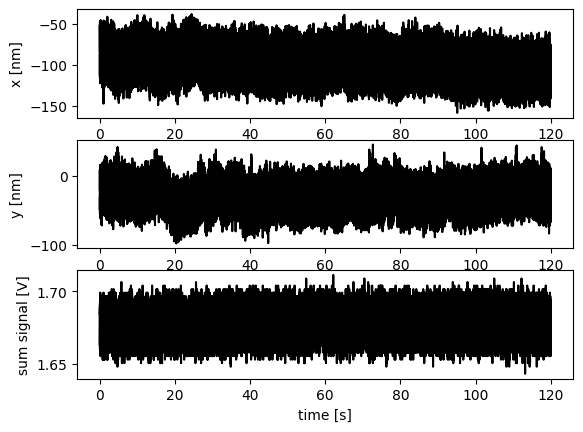

In [ ]:
pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/weisz/250321/'

if 'Sx' in globals():
  del Sx
  del Sy
  del trapx
  del trapy
  del kx
  del ky


xb, yb, sumsignalb, fg, f2, powerspecx2, powerspecy2 = loaddata('Brownian/Brownian_', 0, 120, 1)
calibrate(xb, yb, sumsignalb, f2, powerspecx2, powerspecy2)


# STEP 2: Function generator calibration

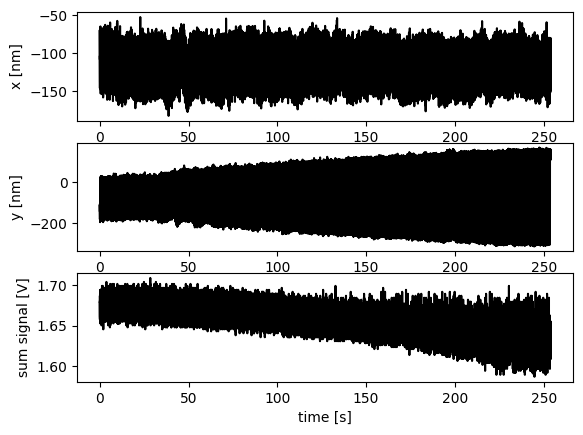

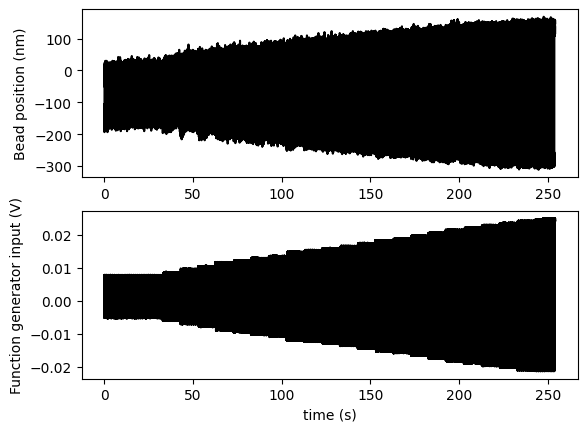

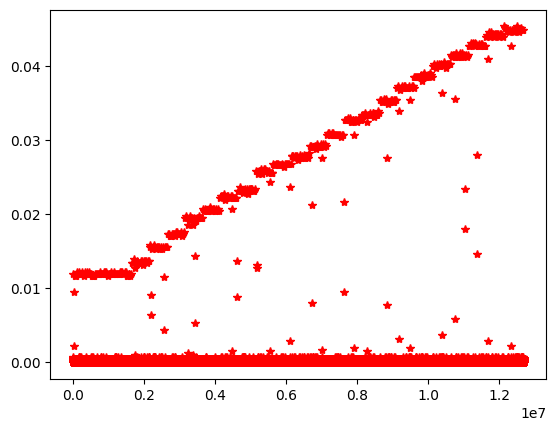

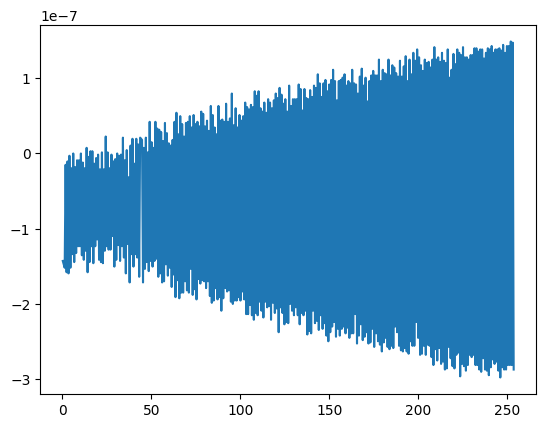

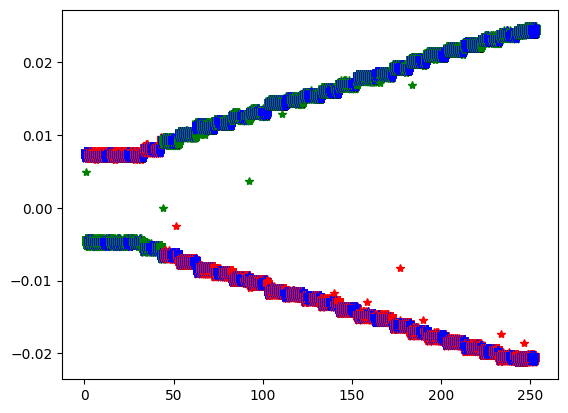

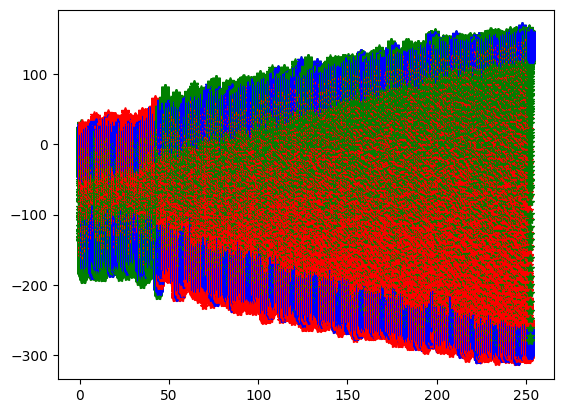

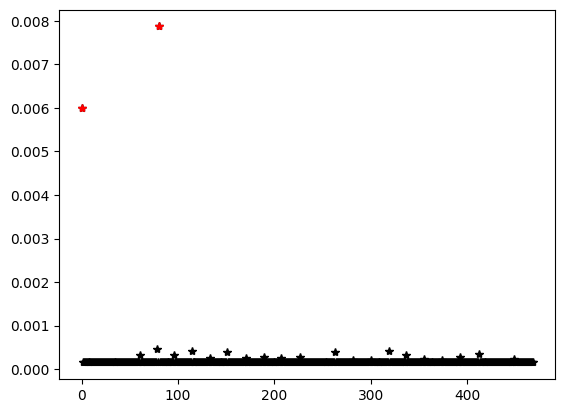

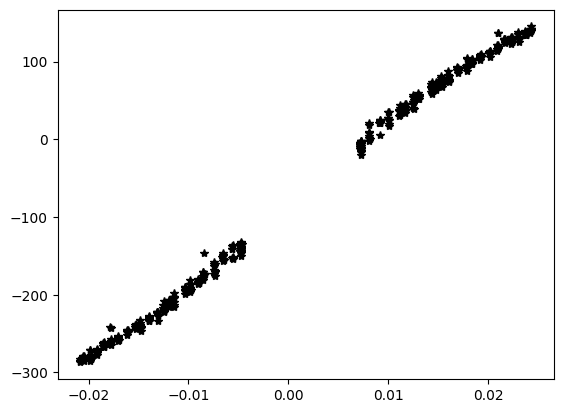

In [ ]:
pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/weisz/250321/'
# Load in the data
x, y,  sumsignalb, fg = loaddata('FunctionG2/FunctionG2_', 0, 254, 0)
Vx, Vy,  sumsignalb, fg = loaddataquiet_nocalib('FunctionG2/FunctionG2_', 0, 254, 0)

times = np.arange(0, len(fg)*dt, dt)

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(times, y*1e9, 'k')
plt.ylabel('Bead position (nm)')
plt.subplot(2, 1, 2)
plt.plot(times, fg, 'k')
plt.ylabel('Function generator input (V)')
plt.xlabel('time (s)')

# look for the transition points, where the function generator signla jumps
absdiff = np.append(np.abs(np.diff(fg)), 0)
#plt.figure()
#plt.plot(times, absdiff, 'k')
index = absdiff>(np.mean(absdiff)*100)
indexvalues = np.arange(0, len(index), 1)

plt.figure()
plt.plot(absdiff, 'r*')
plt.show()
plt.figure()
plt.plot(times[index], y[index])
plt.show()

# reduce the transtion points with multiple consecutive points to a single point
indexvaluesmarked = indexvalues[index]
indexvalueskeep = np.array([])
oldindex = indexvaluesmarked[0]
for i in range(1, len(indexvaluesmarked)):
  if indexvaluesmarked[i] == oldindex + 1:
    oldindex = indexvaluesmarked[i]
  else:
    indexvalueskeep = np.append(indexvalueskeep, oldindex)
    oldindex = indexvaluesmarked[i]


# Plot of the oscillating function generator signal, blue is where the calibration will be calculated
# calculation is done between (0.85 and 0.95 of the period) following the transition
plt.figure()
stdfg = np.array([])
for i in range(len(indexvalueskeep)-1):
   rangeval = (times > (times[int(indexvalueskeep[i])])) * (times < (times[int(indexvalueskeep[i+1])]))
   if int(i/2) == int(i)/2:
     plt.plot(times[rangeval], fg[rangeval] , 'g*')
     stdfg = np.append(stdfg, np.std(fg[rangeval]))
   else:
     plt.plot(times[rangeval], fg[rangeval] , 'r*')
     stdfg = np.append(stdfg, np.std(fg[rangeval]))

   rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.85)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
   plt.plot(times[rangeval],fg[rangeval], 'b*')

# Plot of the oscillating y signal, blue is where the calibration will be calculated
plt.figure()
for i in range(len(indexvalueskeep)-1):
   rangeval = (times > (times[int(indexvalueskeep[i])])) * (times < (times[int(indexvalueskeep[i+1])]))
   if int(i/2) == int(i)/2:
     plt.plot(times[rangeval], 1e9*y[rangeval] , 'g*')
   else:
     plt.plot(times[rangeval], 1e9*y[rangeval] , 'r*')

   rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.85)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
   plt.plot(times[rangeval],1e9*y[rangeval], 'b*')

# Plot to help us see what data are being thrown away because the amplitude at the fg is being varied
oscilnumber = np.arange(0, len(stdfg), 1)
plt.figure()
plt.plot(oscilnumber, stdfg, 'k*')
plt.plot(oscilnumber[stdfg>5*np.mean(stdfg)], stdfg[stdfg>5*np.mean(stdfg)], 'r*')

# This is our final calibration plot
plt.figure()
meanfgvals = np.array([])
meanyvals = np.array([])
meanVyvals = np.array([])
for i in range(len(indexvalueskeep)-1):
  if stdfg[i]<1.1*np.mean(stdfg):
    rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.75)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
    meanfg = np.mean(fg[rangeval])
    meany = np.mean(y[rangeval])
    meanVy = np.mean(Vy[rangeval])
    plt.plot(meanfg, meany*1e9, 'k*')

    meanfgvals = np.append(meanfgvals, meanfg)
    meanyvals = np.append(meanyvals, meany)
    meanVyvals = np.append(meanVyvals, meanVy)

  else:
    #print('skip oscillation: ', i) # these are where we were changing the amplitude in the middle of the oscillation
    pass


### Take the function generator data, and fit it to get the calibration

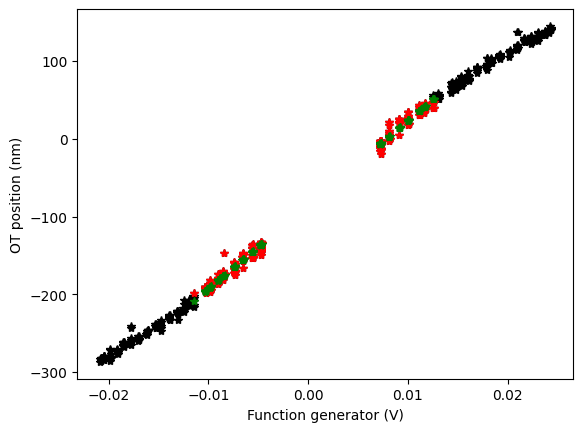

In [ ]:
plt.figure()
meanfgvals = np.array([])
meanyvals = np.array([])
meanVyvals = np.array([])
for i in range(len(indexvalueskeep)-1):
  if stdfg[i]<5*np.mean(stdfg):
    rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.75)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
    meanfg = np.mean(fg[rangeval])
    meany = np.mean(y[rangeval])
    meanVy = np.mean(Vy[rangeval])
    plt.plot(meanfg, meany*1e9, 'k*')

    meanfgvals = np.append(meanfgvals, meanfg)
    meanyvals = np.append(meanyvals, meany)
    meanVyvals = np.append(meanVyvals, meanVy)

  else:
    #print('skip oscillation: ', i) # these are where we were changing the amplitude in the middle of the oscillation
    pass

# if we only trust the detector to a few 100 nm's away from the center, we should fit from about -400 <--> 400 along the y-detection
index = (meanyvals >  -200*1e-9)*(meanyvals < 50*1e-9)
plt.plot(meanfgvals[index], 1e9*meanyvals[index], 'r*')

# Fitting a line
afit, bfit = np.polyfit(meanfgvals[index], 1e9*meanyvals[index], 1)
plt.plot(meanfgvals[index], afit * meanfgvals[index] + bfit, 'g*')
plt.ylabel('OT position (nm)')
plt.xlabel('Function generator (V)')

def OTposconversion(fgvals, afit, bfit):
  return afit * fgvals + bfit


# Calibrate the entire detector along the y-axis - THIS IS A NEW IDEA we are trying

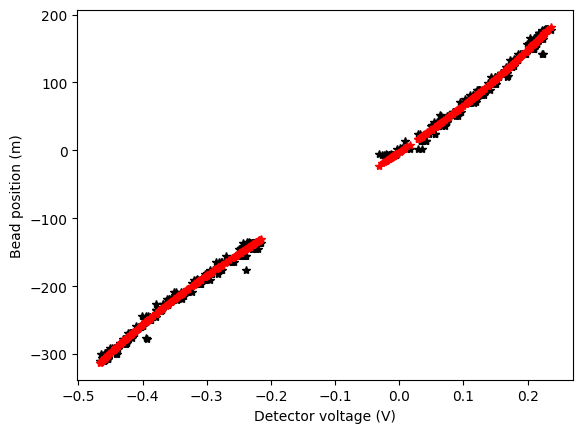

In [ ]:
# Plot the bead position as a function of the position measured by the detector

actual_beadpos = OTposconversion(meanfgvals, afit, bfit)
detector_V = meanVyvals

index = (actual_beadpos>-400)*(actual_beadpos<300)

plt.plot(detector_V[index], actual_beadpos[index], 'k*')
plt.xlabel('Detector voltage (V)')
plt.ylabel('Bead position (m)')

# Fitting a polynomial
afit_det, bfit_det, cfit_det, dfit_det = np.polyfit(detector_V[index], actual_beadpos[index], 3)
plt.plot(detector_V[index], afit_det * detector_V[index]**3 + bfit_det * detector_V[index]**2 + cfit_det *detector_V[index]+dfit_det, 'r*')

def ypos_conversion(Vy, afit_det, bfit_det, cfit_det, dfit_det):
  return afit_det * Vy**3 + bfit_det * Vy**2 + cfit_det *Vy +dfit_det

def loaddata_ed(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    #longdatax = (longdatax)/(Sx/1e9)-trapx
    #longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatay = 1e-9*ypos_conversion(longdatay, afit_det, bfit_det, cfit_det, dfit_det)
    longdatax = (longdatax)/(Sx)    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg

def loaddataquiet_ed(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = np.array([])
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:
        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    longdatay = 1e-9*ypos_conversion(longdatay, afit_det, bfit_det, cfit_det, dfit_det)
    longdatax = (longdatax)/(Sx)    # all in meters

  else:
    pass

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg
